# Notebook 13: LSTM Gentrification Prediction Prototype

**Objective:** Build a PyTorch LSTM that predicts gentrification class (0/1/2) per neighborhood cluster from temporal CVR business data.  
Spatial-join 341K business points to 1,421 clusters, aggregate industry counts per 5-year window (6 time steps), learn DB25 embeddings, and train an LSTM classifier — directly comparable with the XGBoost baseline (Notebook 05).

**Phases:**
1. Data Pipeline & Storage
2. Feature Engineering & Embeddings
3. PyTorch LSTM Model & Training

## Phase 1 — Data Pipeline

In [94]:
# Cell 1: Imports & config
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Paths (relative from notebooks/) ──
CVR_GEO_PATH       = Path("../data/processed/cvr/CVR_geo_temporal.geojson")
#CLUSTER_SHP_PATH   = Path("../data/raw/neighborhood_shapefile/Nabolag_cph_fre_new.shp")
CLUSTER_SHP_PATH   = Path("../data/raw/nabolag_inkl_y_kom_shapefile/cluster_outer_v1.shp") # change between different clister setup
TARGET_PATH        = Path("../data/processed/classified_gt/classified_combined_5yr_quantile.gpkg")  # 5-year tertile rank aggregation
#TARGET_PATH       = Path("../data/processed/classified_gt/classified_combined.gpkg")               # 10-year σ-band (original)
#TARGET_PATH       = Path("../data/processed/classified_gt/classified_combined_consec2.gpkg")        # consec2 strict
PARQUET_OUT_PATH   = Path("../data/processed/cvr/cvr_cluster_temporal_counts.parquet")
MODEL_OUT_PATH     = Path("../results/models/lstm_gentrification.pt")
PRED_OUT_PATH      = Path("../results/models/lstm_predictions.csv")

# ── Temporal periods (matching XGBoost notebook 05) ──
PERIODS = [
    (1990, 1995),
    (1995, 2000),
    (2000, 2005),
    (2005, 2010),
    (2010, 2015),
    (2015, 2020),
]
NUM_PERIODS = len(PERIODS)

# ── Reproducibility ──
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

PyTorch 2.11.0+cpu | Device: cpu


In [95]:
# Cell 2: Load CVR GeoJSON, parse dates, reproject to EPSG:25832
print("Loading CVR_geo_temporal.geojson ...")
cvr_gdf = gpd.read_file(CVR_GEO_PATH)
print(f"Loaded {len(cvr_gdf):,} business features | CRS: {cvr_gdf.crs}")

# Parse dates
for col in ["produktionsenhedStartdato", "produktionsenhedOphoersdato",
            "virksomhedStartdato", "virksomhedOphoersdato"]:
    if col in cvr_gdf.columns:
        cvr_gdf[col] = pd.to_datetime(cvr_gdf[col], errors="coerce")

# Use produktionsenhed dates as primary; fall back to virksomhed dates
cvr_gdf["start_date"] = cvr_gdf["produktionsenhedStartdato"].fillna(
    cvr_gdf["virksomhedStartdato"]
)
cvr_gdf["end_date"] = cvr_gdf["produktionsenhedOphoersdato"].fillna(
    cvr_gdf["virksomhedOphoersdato"]
)

# Reproject WGS84 → EPSG:25832
if cvr_gdf.crs is None or cvr_gdf.crs.to_epsg() != 25832:
    cvr_gdf = cvr_gdf.to_crs(epsg=25832)
    print(f"Reprojected to EPSG:25832")

# Drop rows without geometry
before = len(cvr_gdf)
cvr_gdf = cvr_gdf[cvr_gdf.geometry.notna()].copy()
print(f"Dropped {before - len(cvr_gdf):,} rows with null geometry → {len(cvr_gdf):,} remaining")

# Use full 6-digit DB25 code (branche_kode) instead of 2-digit prefix
cvr_gdf["db25"] = cvr_gdf["branche_kode"].astype(str).str.strip()
print(f"Unique 6-digit DB25 codes: {cvr_gdf['db25'].nunique()}")
cvr_gdf.head(3)

Loading CVR_geo_temporal.geojson ...
Loaded 332,071 business features | CRS: EPSG:4326
Reprojected to EPSG:25832
Dropped 0 rows with null geometry → 332,071 remaining
Unique 6-digit DB25 codes: 1574


,CVRNummer,navn,virksomhedStartdato,virksomhedOphoersdato,branche_kode,branche_navn,CVREnhedsId,Adresse,pNummer,tilknyttetVirksomhedsCVRNummer,produktionsenhedStartdato,produktionsenhedOphoersdato,geometry,start_date,end_date,db25
0,13412731,CARNEGIE ASSET ADMINISTRATION A/S,1989-08-01,2019-06-11,661900,Andre hjælpetjenester i forbindelse med finans...,4002799827,d8f92e9d-db74-45b0-89b2-973686e16809,1000558874,13412731,1989-08-01,2019-06-11,POINT (725925.52 6178533.39),1989-08-01,2019-06-11,661900
1,40240918,PLANICO ApS,1972-05-16,NaT,692000,Bogføring og revision; skatterådgivning,4002318166,0a3f50a4-14d9-32b8-e044-0003ba298018,1001793715,40240918,2000-01-28,NaT,POINT (721134.21 6184230.03),2000-01-28,NaT,692000
2,81090416,"ERIK CHRISTENSEN & SØN, BIRKERØD A/S",1977-11-04,NaT,511100,"Agenturhandel med råvarer til landbruget, land...",4003147554,c44181eb-7625-4844-93ce-6fde4d89e444,1002971450,81090416,1991-01-01,2010-11-25,POINT (724033.54 6174859),1991-01-01,2010-11-25,511100


In [96]:
# Cell 3: Spatial join — assign cluster_id to each business
print("Loading cluster polygons ...")
clusters = gpd.read_file(CLUSTER_SHP_PATH)
print(f"Loaded {len(clusters):,} cluster polygons | CRS: {clusters.crs}")
print(f"Columns: {list(clusters.columns)}")

# Pick the right join key (avoid duplicate after rename)
if "munic_clus" in clusters.columns:
    join_key = "munic_clus"
elif "cluster_id" in clusters.columns:
    join_key = "cluster_id"
else:
    raise KeyError("No munic_clus or cluster_id column found in shapefile")

# Keep only the join key + geometry, then rename to cluster_id
clusters_slim = clusters[[join_key, "geometry"]].copy()
clusters_slim = clusters_slim.rename(columns={join_key: "cluster_id"})

# Spatial join (inner keeps only businesses inside a polygon)
print("Running spatial join ...")
cvr_joined = gpd.sjoin(cvr_gdf, clusters_slim, how="inner", predicate="within")

match_rate = len(cvr_joined) / len(cvr_gdf) * 100
print(f"Matched {len(cvr_joined):,} / {len(cvr_gdf):,} businesses ({match_rate:.1f}%)")
print(f"Businesses assigned to {cvr_joined['cluster_id'].nunique()} unique clusters")

Loading cluster polygons ...
Loaded 2,232 cluster polygons | CRS: EPSG:25832
Columns: ['fid', 'munic_code', 'id_munic', 'area', 'cluster_id', 'geometry']
Running spatial join ...
Matched 276,010 / 332,071 businesses (83.1%)
Businesses assigned to 2224 unique clusters


In [97]:
# Cell 4: Temporal bucketing — determine which periods each business was active
def assign_periods(row):
    """Return list of period indices where the business was active."""
    start = row["start_date"]
    end   = row["end_date"]
    start_year = start.year if pd.notna(start) else 1900
    end_year   = end.year   if pd.notna(end)   else 2026  # still active
    active = []
    for i, (p_start, p_end) in enumerate(PERIODS):
        if start_year < p_end and end_year >= p_start:
            active.append(i)
    return active

print("Assigning businesses to 5-year periods ...")
cvr_joined["active_periods"] = cvr_joined.apply(assign_periods, axis=1)

# Explode so each row = one business × one period
cvr_exploded = cvr_joined.explode("active_periods")
cvr_exploded = cvr_exploded.dropna(subset=["active_periods"])
cvr_exploded["period_idx"] = cvr_exploded["active_periods"].astype(int)

print(f"Exploded to {len(cvr_exploded):,} business-period rows")
print(f"Period distribution:")
for i, (ps, pe) in enumerate(PERIODS):
    n = (cvr_exploded["period_idx"] == i).sum()
    print(f"  {ps}-{pe}: {n:,} active businesses")

Assigning businesses to 5-year periods ...
Exploded to 567,320 business-period rows
Period distribution:
  1990-1995: 28,325 active businesses
  1995-2000: 48,577 active businesses
  2000-2005: 75,883 active businesses
  2005-2010: 96,773 active businesses
  2010-2015: 130,338 active businesses
  2015-2020: 187,424 active businesses


In [98]:
# Cell 5: Aggregate — count businesses per (cluster_id, period, db25) + gentrified flag
# ── Load gentrified industry codes ──
GENT_IND_PATH = Path("../data/raw/cvr_raw/industry_ids/Gentrified_business_certain_industry_id.csv")
gent_df = pd.read_csv(GENT_IND_PATH, sep=";", encoding="latin-1")
gent_codes = set(gent_df["industry-id"].astype(str).str.strip())
print(f"Loaded {len(gent_codes)} gentrified industry codes")

# Flag each business as gentrified or not (match on full 6-digit branche_kode)
cvr_exploded["is_gentrified"] = cvr_exploded["db25"].isin(gent_codes).astype(int)
gent_rate = cvr_exploded["is_gentrified"].mean()
print(f"Gentrified businesses: {cvr_exploded['is_gentrified'].sum():,} / {len(cvr_exploded):,} ({gent_rate:.1%})")

# ── DB25 6-digit counts per cluster × period ──
print("Aggregating business counts per cluster × period × DB25 6-digit code ...")
agg = (
    cvr_exploded
    .groupby(["cluster_id", "period_idx", "db25"])
    .size()
    .reset_index(name="count")
)

pivot = agg.pivot_table(
    index=["cluster_id", "period_idx"],
    columns="db25",
    values="count",
    fill_value=0,
).reset_index()

db25_cols = [c for c in pivot.columns if c not in ("cluster_id", "period_idx")]
pivot.columns.name = None
pivot["total_businesses"] = pivot[db25_cols].sum(axis=1)

# ── Normalise DB25 counts → share of total businesses (size-invariant composition) ──
# Each DB25 column becomes: count(cluster, period, code) / total_businesses(cluster, period)
# This removes neighbourhood-size bias; larger neighbourhoods no longer look "more gentrified"
denom = pivot["total_businesses"].replace(0, 1)   # avoid div-by-zero for empty periods
pivot[db25_cols] = pivot[db25_cols].div(denom, axis=0)
print("Normalised DB25 columns to shares of total businesses per cluster-period")

# ── Gentrified business ratio per cluster × period ──
# gentrified_ratio = gentrified_count / total_businesses (consistent with share normalisation)
gent_agg = (
    cvr_exploded
    .groupby(["cluster_id", "period_idx"])["is_gentrified"]
    .agg(gentrified_count="sum", gentrified_ratio="mean")
    .reset_index()
)
pivot = pivot.merge(gent_agg, on=["cluster_id", "period_idx"], how="left")
pivot["gentrified_count"] = pivot["gentrified_count"].fillna(0)
pivot["gentrified_ratio"] = pivot["gentrified_ratio"].fillna(0)

print(f"Aggregated shape: {pivot.shape}")
print(f"DB25 6-digit columns (as shares): {len(db25_cols)}")
print(f"Unique clusters in aggregation: {pivot['cluster_id'].nunique()}")
print(f"Extra columns: total_businesses (raw count), gentrified_count, gentrified_ratio")
pivot.head()


Loaded 21 gentrified industry codes
Gentrified businesses: 12,002 / 567,320 (2.1%)
Aggregating business counts per cluster × period × DB25 6-digit code ...
Normalised DB25 columns to shares of total businesses per cluster-period
Aggregated shape: (13211, 1520)
DB25 6-digit columns (as shares): 1515
Unique clusters in aggregation: 2224
Extra columns: total_businesses (raw count), gentrified_count, gentrified_ratio


,cluster_id,period_idx,011100,011110,011190,011210,011220,011300,011600,011900,...,981000,982000,990000,990010,990020,999999,None,total_businesses,gentrified_count,gentrified_ratio
0,101_1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,3.0,0,0.0
1,101_1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.125000,0.0,8.0,0,0.0
2,101_1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.142857,0.0,7.0,0,0.0
3,101_1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.052632,0.0,19.0,0,0.0
4,101_1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.085714,0.0,35.0,0,0.0


In [99]:
# Cell 6: Save to Parquet + verify coverage
PARQUET_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
pivot.to_parquet(PARQUET_OUT_PATH, index=False)
print(f"Saved aggregated data to {PARQUET_OUT_PATH} ({PARQUET_OUT_PATH.stat().st_size/1024:.0f} KB)")

# Load target labels to check coverage
sta = gpd.read_file(TARGET_PATH)[["cluster_id", "combined_class_idx"]]
target_clusters = set(sta["cluster_id"].astype(str))
agg_clusters = set(pivot["cluster_id"].astype(str))

covered = target_clusters & agg_clusters
missing = target_clusters - agg_clusters
print(f"\nTarget clusters (classified_combined): {len(target_clusters)}")
print(f"Clusters with CVR data:                {len(agg_clusters)}")
print(f"Overlap:                               {len(covered)} ({len(covered)/len(target_clusters)*100:.1f}%)")
if missing:
    print(f"Missing clusters (no CVR data): {len(missing)}")

# Class distribution in target
print(f"\nTarget class distribution (combined_class_idx):")
print(sta["combined_class_idx"].value_counts().sort_index())


Saved aggregated data to ..\data\processed\cvr\cvr_cluster_temporal_counts.parquet (2911 KB)

Target clusters (classified_combined): 2232
Clusters with CVR data:                2224
Overlap:                               2224 (99.6%)
Missing clusters (no CVR data): 8

Target class distribution (combined_class_idx):
combined_class_idx
0.0    954
1.0    734
2.0    544
Name: count, dtype: int64


## Phase 2 — Feature Engineering & Dataset

In [100]:
# Cell 7: Build sequence tensors
# Reload from Parquet (allows skipping Phase 1 on re-runs)
pivot = pd.read_parquet(PARQUET_OUT_PATH)
sta = gpd.read_file(TARGET_PATH)[["cluster_id", "combined_class_idx"]]

# Identify feature columns (all DB25 6-digit codes + summary cols)
meta_cols = ["cluster_id", "period_idx"]
non_db25 = {"total_businesses", "gentrified_count", "gentrified_ratio"}
feature_cols = [c for c in pivot.columns if c not in meta_cols]
print(f"Feature columns ({len(feature_cols)}): {feature_cols[:10]} ...")

# Build DB25 vocabulary for embedding — exclude non-DB25 summary columns
db25_cols = [c for c in feature_cols if c not in non_db25]
db25idx = {code: i for i, code in enumerate(sorted(db25_cols))}
idx2db25 = {i: code for code, i in db25idx.items()}
NUM_DB25 = len(db25idx)
print(f"DB25 vocabulary: {NUM_DB25} unique 6-digit codes")
print(f"Non-DB25 feature columns kept: {sorted(non_db25 & set(feature_cols))}")

# ── Drop sparse DB25 columns (>95% zeros → noise, not signal) ──
db25_sparsity = {c: (pivot[c] == 0).mean() for c in db25_cols}
sparse_cols = [c for c, s in db25_sparsity.items() if s > 0.95]
kept_db25 = [c for c in db25_cols if c not in sparse_cols]
print(f"Dropping {len(sparse_cols)} sparse DB25 columns (>95% zeros): {sparse_cols[:10]}{'...' if len(sparse_cols)>10 else ''}")
print(f"Keeping {len(kept_db25)} DB25 columns")

# Update feature_cols and db25_cols after filtering
db25_cols = kept_db25
feature_cols = db25_cols + sorted(non_db25 & set(feature_cols))
db25idx = {code: i for i, code in enumerate(sorted(db25_cols))}
idx2db25 = {i: code for code, i in db25idx.items()}
NUM_DB25 = len(db25idx)

# Ensure all clusters have all 6 periods (fill missing periods with zeros)
all_clusters = sorted(pivot["cluster_id"].unique())
all_periods = list(range(NUM_PERIODS))

full_index = pd.MultiIndex.from_product(
    [all_clusters, all_periods], names=["cluster_id", "period_idx"]
)
pivot_full = (
    pivot.set_index(["cluster_id", "period_idx"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)
print(f"Full matrix: {pivot_full.shape[0]} rows = {len(all_clusters)} clusters × {NUM_PERIODS} periods")
print(f"Final feature count: {len(feature_cols)}")


Feature columns (1518): ['011100', '011110', '011190', '011210', '011220', '011300', '011600', '011900', '012100', '012110'] ...
DB25 vocabulary: 1515 unique 6-digit codes
Non-DB25 feature columns kept: ['gentrified_count', 'gentrified_ratio', 'total_businesses']
Dropping 1372 sparse DB25 columns (>95% zeros): ['011100', '011110', '011190', '011210', '011220', '011300', '011600', '011900', '012100', '012110']...
Keeping 143 DB25 columns
Full matrix: 13344 rows = 2224 clusters × 6 periods
Final feature count: 146


In [101]:

# Cell 8: Prepare target labels + train/val/test split + spatial coordinates
sta["cluster_id"] = sta["cluster_id"].astype(str)
pivot_full["cluster_id"] = pivot_full["cluster_id"].astype(str)

# ── Extract spatial centroids from TARGET_PATH ──
_geo = gpd.read_file(TARGET_PATH)[["cluster_id", "geometry"]]
_geo["cluster_id"] = _geo["cluster_id"].astype(str)
_geo = _geo.to_crs("EPSG:25832")
_geo["cx"] = _geo.geometry.centroid.x
_geo["cy"] = _geo.geometry.centroid.y
_cx_min, _cx_max = _geo["cx"].min(), _geo["cx"].max()
_cy_min, _cy_max = _geo["cy"].min(), _geo["cy"].max()
_geo["cx_norm"] = (_geo["cx"] - _cx_min) / (_cx_max - _cx_min)
_geo["cy_norm"] = (_geo["cy"] - _cy_min) / (_cy_max - _cy_min)
coord_map = {
    r["cluster_id"]: np.array([r["cx_norm"], r["cy_norm"]], dtype=np.float32)
    for _, r in _geo.iterrows()
}
print(f"Spatial centroids extracted for {len(coord_map)} clusters (EPSG:25832, normalized to [0,1])")

# Valid clusters: intersection of CVR data, target labels, and coordinates
valid_clusters = sorted(
    set(pivot_full["cluster_id"].unique())
    & set(sta["cluster_id"].unique())
    & set(coord_map.keys())
)
print(f"Clusters with CVR data, target label, and coordinates: {len(valid_clusters)}")

# Build class target map (classification only — regression head dropped)
target_map = sta.set_index("cluster_id")["combined_class_idx"].to_dict()
y_all_class = np.array([int(target_map[c]) for c in valid_clusters])

# ── Binary remapping: collapse Class 1 (medium) + Class 2 (high) → Gentrified ──
# New labels: 0 = Not Gentrified (stable), 1 = Gentrified (medium OR high gentrification)
y_all_class = np.where(y_all_class > 0, 1, 0)
print(f"Binary class distribution: {dict(zip(*np.unique(y_all_class, return_counts=True)))}")

# Stratified train / val / test split (60 / 20 / 20)
train_clusters, temp_clusters, y_train_cls, y_temp_cls = train_test_split(
    valid_clusters, y_all_class, test_size=0.4, random_state=RANDOM_STATE, stratify=y_all_class
)
val_clusters, test_clusters, y_val_cls, y_test_cls = train_test_split(
    temp_clusters, y_temp_cls, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp_cls
)

print(f"\nTrain: {len(train_clusters)} | Val: {len(val_clusters)} | Test: {len(test_clusters)}")
for split_name, labels in [("Train", y_train_cls), ("Val", y_val_cls), ("Test", y_test_cls)]:
    counts = np.bincount(labels, minlength=2)
    print(f"  {split_name} class distribution: {dict(enumerate(counts))}")


Spatial centroids extracted for 2232 clusters (EPSG:25832, normalized to [0,1])
Clusters with CVR data, target label, and coordinates: 2224
Binary class distribution: {np.int64(0): np.int64(952), np.int64(1): np.int64(1272)}

Train: 1334 | Val: 445 | Test: 445
  Train class distribution: {0: np.int64(571), 1: np.int64(763)}
  Val class distribution: {0: np.int64(190), 1: np.int64(255)}
  Test class distribution: {0: np.int64(191), 1: np.int64(254)}


In [102]:

# Cell 9: Augment features — deltas + diversity — normalize & build sequence/coord tensors
from scipy.stats import entropy as sp_entropy

enriched_rows = []
for cid in pivot_full["cluster_id"].unique():
    mask = pivot_full["cluster_id"] == cid
    cluster_data = pivot_full.loc[mask].sort_values("period_idx")
    feats = cluster_data[feature_cols].values  # (6, F)

    # Temporal deltas (period-over-period change) — explicit trend signal
    deltas = np.diff(feats, axis=0, prepend=feats[:1])

    db25_feat_idx = [feature_cols.index(c) for c in db25_cols]
    total_idx = feature_cols.index("total_businesses")

    for i in range(NUM_PERIODS):
        row = {"cluster_id": cid, "period_idx": i}

        for j, col in enumerate(feature_cols):
            row[f"d_{col}"] = deltas[i, j]

        total = feats[i, total_idx]
        db25_counts = feats[i, db25_feat_idx]
        if total > 0:
            proportions = db25_counts / total
            row["shannon_diversity"] = sp_entropy(db25_counts + 1e-10)
            row["num_active_sectors"] = (db25_counts > 0).sum()
            row["herfindahl_idx"] = np.sum(proportions ** 2)
        else:
            row["shannon_diversity"] = 0.0
            row["num_active_sectors"] = 0
            row["herfindahl_idx"] = 0.0

        enriched_rows.append(row)

enriched_df = pd.DataFrame(enriched_rows)
delta_cols = [c for c in enriched_df.columns if c.startswith("d_")]
diversity_cols = ["shannon_diversity", "num_active_sectors", "herfindahl_idx"]

pivot_aug = pivot_full.merge(enriched_df, on=["cluster_id", "period_idx"], how="left")
aug_feature_cols = feature_cols + delta_cols + diversity_cols
print(f"Augmented features: {len(feature_cols)} original + {len(delta_cols)} deltas "
      f"+ {len(diversity_cols)} diversity = {len(aug_feature_cols)} total")

# ── Normalize & build sequence tensors ──
scaler = MinMaxScaler()

def build_sequences(cluster_list, fit_scaler=False, scaler_obj=None):
    """
    Build (N, T, F) tensor. Pass scaler_obj for a fold-local scaler (k-fold CV).
    When fit_scaler=True the scaler is fitted on this cluster list's data.
    """
    _sc = scaler_obj if scaler_obj is not None else scaler
    sequences = []
    for cid in cluster_list:
        mask = pivot_aug["cluster_id"] == cid
        cluster_data = pivot_aug.loc[mask].sort_values("period_idx")
        sequences.append(cluster_data[aug_feature_cols].values)
    arr = np.stack(sequences)           # (N, T, F)
    N, T, F = arr.shape
    flat = arr.reshape(-1, F)
    flat = _sc.fit_transform(flat) if fit_scaler else _sc.transform(flat)
    return torch.tensor(flat.reshape(N, T, F), dtype=torch.float32)

def get_coords(cluster_list):
    """Return (N, 2) float32 tensor of normalized [cx, cy] centroids."""
    coords = np.stack([coord_map[c] for c in cluster_list])
    return torch.tensor(coords, dtype=torch.float32)

X_train = build_sequences(train_clusters, fit_scaler=True)
X_val   = build_sequences(val_clusters)
X_test  = build_sequences(test_clusters)

C_train = get_coords(train_clusters)
C_val   = get_coords(val_clusters)
C_test  = get_coords(test_clusters)

print(f"X_train: {X_train.shape}  C_train: {C_train.shape}")
print(f"X_val:   {X_val.shape}    C_val:   {C_val.shape}")
print(f"X_test:  {X_test.shape}   C_test:  {C_test.shape}")
print(f"Feature dim: {X_train.shape[2]}")


Augmented features: 146 original + 146 deltas + 3 diversity = 295 total
X_train: torch.Size([1334, 6, 295])  C_train: torch.Size([1334, 2])
X_val:   torch.Size([445, 6, 295])    C_val:   torch.Size([445, 2])
X_test:  torch.Size([445, 6, 295])   C_test:  torch.Size([445, 2])
Feature dim: 295


In [103]:

# Cell 9b: Sequence SMOTE — oversample minority classes on training sequences + spatial coords
from sklearn.utils import check_random_state

def sequence_smote(X_tensor, C_tensor, y_cls_array, random_state=42):
    """
    Linear-interpolation SMOTE for (N, T, F) sequential tensors + (N, 2) coordinates.
    Upsamples each minority class to match the majority class count.
    Coordinates are spatially interpolated between the two parent samples.
    """
    rng = check_random_state(random_state)
    X_np = X_tensor.numpy()
    C_np = C_tensor.numpy()

    class_counts_s = np.bincount(y_cls_array)
    target_n = class_counts_s.max()

    X_list, C_list, y_cls_list = [X_np], [C_np], [y_cls_array]

    for cls in range(len(class_counts_s)):
        cls_idx = np.where(y_cls_array == cls)[0]
        n_needed = target_n - len(cls_idx)
        if n_needed <= 0:
            continue

        i1s  = rng.choice(cls_idx, size=n_needed, replace=True)
        i2s  = rng.choice(cls_idx, size=n_needed, replace=True)
        lams = rng.uniform(0.2, 0.8, size=n_needed)

        syn_X = lams[:, None, None] * X_np[i1s] + (1 - lams[:, None, None]) * X_np[i2s]
        syn_C = lams[:, None]       * C_np[i1s] + (1 - lams[:, None])       * C_np[i2s]

        X_list.append(syn_X)
        C_list.append(syn_C)
        y_cls_list.append(np.full(n_needed, cls, dtype=y_cls_array.dtype))

    X_aug  = np.concatenate(X_list,     axis=0)
    C_aug  = np.concatenate(C_list,     axis=0).astype(np.float32)
    y_aug  = np.concatenate(y_cls_list, axis=0)

    perm = rng.permutation(len(y_aug))
    return (
        torch.tensor(X_aug[perm], dtype=torch.float32),
        torch.tensor(C_aug[perm], dtype=torch.float32),
        y_aug[perm],
    )

print("Applying Sequence SMOTE to training data ...")
before_dist = np.bincount(y_train_cls)
X_train_aug, C_train_aug, y_train_cls_aug = sequence_smote(X_train, C_train, y_train_cls)
after_dist = np.bincount(y_train_cls_aug)

print(f"Before SMOTE: {X_train.shape[0]} samples   {dict(enumerate(before_dist.tolist()))}")
print(f"After  SMOTE: {X_train_aug.shape[0]} samples  {dict(enumerate(after_dist.tolist()))}")
print(f"Tensor shape: {X_train_aug.shape} | Coord shape: {C_train_aug.shape}")


Applying Sequence SMOTE to training data ...
Before SMOTE: 1334 samples   {0: 571, 1: 763}
After  SMOTE: 1526 samples  {0: 763, 1: 763}
Tensor shape: torch.Size([1526, 6, 295]) | Coord shape: torch.Size([1526, 2])


In [104]:

# Cell 10: PyTorch Dataset & DataLoaders — classification only + spatial coords
class GentrificationDataset(Dataset):
    def __init__(self, X, C, y_cls):
        self.X     = X
        self.C     = C
        self.y_cls = y_cls
    def __len__(self):
        return len(self.y_cls)
    def __getitem__(self, idx):
        return self.X[idx], self.C[idx], self.y_cls[idx]

BATCH_SIZE = 64

y_train_cls_t = torch.tensor(y_train_cls_aug, dtype=torch.long)
y_val_cls_t   = torch.tensor(y_val_cls,       dtype=torch.long)
y_test_cls_t  = torch.tensor(y_test_cls,      dtype=torch.long)

train_ds = GentrificationDataset(X_train_aug, C_train_aug, y_train_cls_t)
val_ds   = GentrificationDataset(X_val,       C_val,       y_val_cls_t)
test_ds  = GentrificationDataset(X_test,      C_test,      y_test_cls_t)

# Class weights: computed from POST-SMOTE counts.
# SMOTE produced equal counts per class, so weights ≈ [1, 1].
class_counts_aug = np.bincount(y_train_cls_aug, minlength=2).astype(float)
class_weights    = 1.0 / np.maximum(class_counts_aug, 1)
class_weights    = class_weights / class_weights.sum() * 2   # normalise to sum=2
class_weights_t  = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights (post-SMOTE, uniform): {dict(enumerate(class_weights.round(4)))}")
print(f"  Post-SMOTE counts: {dict(enumerate(class_counts_aug.astype(int).tolist()))}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")
print(f"Training samples (post-SMOTE): {len(train_ds)}")


Class weights (post-SMOTE, uniform): {0: np.float64(1.0), 1: np.float64(1.0)}
  Post-SMOTE counts: {0: 763, 1: 763}
Batches — train: 24 | val: 7 | test: 7
Training samples (post-SMOTE): 1526


## Phase 3 — LSTM Model & Training

In [105]:

# Cell 11: BiLSTM + temporal attention — 2-class binary softmax + FocalLoss + spatial context
import torch.nn.functional as F


class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss. gamma focuses training on hard examples;
    alpha (per-class weights) corrects class imbalance.
    label_smoothing=0.1 prevents overconfident predictions on noisy labels.
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha           = alpha
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha,
                             reduction="none",
                             label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


class TemporalAttention(nn.Module):
    """Learnable attention over timesteps — weights each period by importance."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1, bias=False),
        )

    def forward(self, lstm_out):
        scores = self.attn(lstm_out)
        weights = torch.softmax(scores, dim=1)
        context = (lstm_out * weights).sum(dim=1)
        return context, weights.squeeze(-1)


class GentrificationLSTM(nn.Module):
    """
    Bidirectional LSTM with:
      - Optional DB25 industry code embeddings (weighted sum over vocabulary)
      - Feature bottleneck: compresses raw high-dim features before LSTM
      - Temporal attention over 6 periods
      - Static spatial context (normalized centroid coordinates)
      - 2-class binary softmax head (FocalLoss training)
        Class 0 = Stable, Class 1 = Gentrifying (medium OR high)
    """
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, bottleneck_dim=48,
                 num_db25=0, embed_dim=8, num_classes=2, dropout=0.6,
                 spatial_dim=2):
        super().__init__()
        self.num_db25     = num_db25
        self.num_classes  = num_classes
        self.spatial_dim  = spatial_dim

        if num_db25 > 0:
            self.db25_embedding = nn.Embedding(num_db25, embed_dim)
            raw_dim = (input_dim - num_db25) + embed_dim
        else:
            raw_dim = input_dim

        self.layer_norm_in = nn.LayerNorm(raw_dim)
        self.input_proj = nn.Sequential(
            nn.Linear(raw_dim, bottleneck_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )

        self.lstm = nn.LSTM(
            input_size=bottleneck_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.attention      = TemporalAttention(hidden_dim * 2)
        self.layer_norm_out = nn.LayerNorm(hidden_dim * 2)
        self.dropout        = nn.Dropout(dropout)

        # 2-class binary softmax head: 0=Stable, 1=Gentrifying
        self.fc_cls = nn.Linear(hidden_dim * 2 + spatial_dim, num_classes)

    def forward(self, x, coords=None, return_attention=False):
        if self.num_db25 > 0:
            db25_counts    = x[:, :, :self.num_db25]
            other_feats    = x[:, :, self.num_db25:]
            db25_indices   = torch.arange(self.num_db25, device=x.device)
            weighted_embed = torch.matmul(db25_counts, self.db25_embedding(db25_indices))
            x = torch.cat([weighted_embed, other_feats], dim=-1)

        x = self.layer_norm_in(x)
        x = self.input_proj(x)            # (N, T, bottleneck_dim)

        lstm_out, _ = self.lstm(x)
        context, attn_weights = self.attention(lstm_out)
        context = self.layer_norm_out(context)
        out = self.dropout(context)

        if coords is not None and self.spatial_dim > 0:
            out = torch.cat([out, coords], dim=1)   # (N, hidden*2 + spatial_dim)

        cls_logits = self.fc_cls(out)               # (N, num_classes)

        if return_attention:
            return cls_logits, attn_weights
        return cls_logits


INPUT_DIM      = X_train.shape[2]
BOTTLENECK_DIM = 48
HIDDEN_DIM     = 32
NUM_LAYERS     = 1
EMBED_DIM      = 8
DROPOUT        = 0.6
NUM_CLASSES    = 2   # binary: 0=Stable, 1=Gentrifying
SPATIAL_DIM    = 2
FOCAL_GAMMA    = 2.0

model = GentrificationLSTM(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
    bottleneck_dim=BOTTLENECK_DIM, num_db25=NUM_DB25, embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES, dropout=DROPOUT, spatial_dim=SPATIAL_DIM,
).to(DEVICE)

criterion_cls = FocalLoss(alpha=class_weights_t, gamma=FOCAL_GAMMA)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}  (trainable: {trainable:,})")
print(f"Architecture: input({INPUT_DIM}) → bottleneck({BOTTLENECK_DIM}) → "
      f"BiLSTM({HIDDEN_DIM}×2, {NUM_LAYERS}L) → Attention → "
      f"[context|coords({SPATIAL_DIM})] → Softmax({NUM_CLASSES} classes: Stable/Gentrifying)")
print(f"Loss: FocalLoss(gamma={FOCAL_GAMMA}, class_weights={class_weights_t.cpu().numpy().round(3)})")
print(model)


Model parameters: 32,558  (trainable: 32,558)
Architecture: input(295) → bottleneck(48) → BiLSTM(32×2, 1L) → Attention → [context|coords(2)] → Softmax(2 classes: Stable/Gentrifying)
Loss: FocalLoss(gamma=2.0, class_weights=[1. 1.])
GentrificationLSTM(
  (db25_embedding): Embedding(143, 8)
  (layer_norm_in): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
  (input_proj): Sequential(
    (0): Linear(in_features=160, out_features=48, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
  )
  (lstm): LSTM(48, 32, batch_first=True, bidirectional=True)
  (attention): TemporalAttention(
    (attn): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=1, bias=False)
    )
  )
  (layer_norm_out): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc_cls): Linear(in_features=66, out_features=2, bias=True)
)


In [106]:

# Cell 12: Training loop — FocalLoss + composite early stopping + SWA
from sklearn.metrics import f1_score, precision_recall_fscore_support
from torch.optim.swa_utils import AveragedModel, SWALR

LR        = 3e-4
EPOCHS    = 500
PATIENCE  = 60
GRAD_CLIP = 1.0
NOISE_STD = 0.01
SWA_START = 40
SWA_LR    = 5e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=40, T_mult=2, eta_min=1e-6
)
swa_model     = AveragedModel(model)
swa_scheduler = SWALR(optimizer, swa_lr=SWA_LR)


def add_noise(x, std):
    return x + torch.randn_like(x) * std


train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
train_f1s,    val_f1s    = [], []

best_score       = 0.0   # macro-F1
best_val_acc     = 0.0
best_val_loss    = float("inf")
patience_counter = 0
best_state       = None

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    running_loss, total = 0.0, 0
    epoch_preds, epoch_targets = [], []

    for X_batch, C_batch, y_cls_batch in train_loader:
        X_batch     = X_batch.to(DEVICE)
        C_batch     = C_batch.to(DEVICE)
        y_cls_batch = y_cls_batch.to(DEVICE)

        optimizer.zero_grad()
        cls_logits = model(add_noise(X_batch, NOISE_STD), C_batch)
        loss = criterion_cls(cls_logits, y_cls_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        running_loss += loss.item() * len(y_cls_batch)
        total        += len(y_cls_batch)
        epoch_preds.extend(torch.argmax(cls_logits, dim=1).detach().cpu().numpy())
        epoch_targets.extend(y_cls_batch.cpu().numpy())

    train_loss = running_loss / total
    train_acc  = (np.array(epoch_preds) == np.array(epoch_targets)).mean()
    train_f1   = f1_score(epoch_targets, epoch_preds, average="macro", zero_division=0)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    if epoch >= SWA_START:
        swa_model.update_parameters(model)
        swa_scheduler.step()
    else:
        scheduler.step()

    # ── Validate ──
    model.eval()
    running_loss, total = 0.0, 0
    val_preds_ep, val_targets_ep = [], []
    with torch.no_grad():
        for X_batch, C_batch, y_cls_batch in val_loader:
            X_batch     = X_batch.to(DEVICE)
            C_batch     = C_batch.to(DEVICE)
            y_cls_batch = y_cls_batch.to(DEVICE)
            cls_logits  = model(X_batch, C_batch)
            loss = criterion_cls(cls_logits, y_cls_batch)
            running_loss += loss.item() * len(y_cls_batch)
            total        += len(y_cls_batch)
            val_preds_ep.extend(torch.argmax(cls_logits, dim=1).cpu().numpy())
            val_targets_ep.extend(y_cls_batch.cpu().numpy())

    val_loss     = running_loss / total
    val_acc      = (np.array(val_preds_ep) == np.array(val_targets_ep)).mean()
    val_macro_f1 = f1_score(val_targets_ep, val_preds_ep, average="macro", zero_division=0)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_macro_f1)

    # Stopping criterion: pure macro-F1
    _, r_all, _, _ = precision_recall_fscore_support(
        val_targets_ep, val_preds_ep, labels=[0, 1], zero_division=0)
    val_r0    = float(r_all[0])   # Stable recall (monitoring)
    val_score = val_macro_f1      # model selection: pure macro-F1

    if val_score > best_score:
        best_score    = val_score
        best_val_acc  = val_acc
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or patience_counter == PATIENCE:
        swa_tag = " [SWA]" if epoch >= SWA_START else ""
        gap_f1  = train_f1 - val_macro_f1
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {train_loss:.4f}  F1: {train_f1:.3f} | "
              f"Val loss: {val_loss:.4f}  F1: {val_macro_f1:.3f}  R_stable: {val_r0:.3f}  R_gent: {r_all[1]:.3f} | "
              f"Gap: {gap_f1:+.3f} | Pat: {patience_counter}/{PATIENCE}{swa_tag}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}  (best macro-F1: {best_score:.4f})")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)

# ── SWA comparison ──
swa_model.to(DEVICE)
torch.optim.swa_utils.update_bn(train_loader, swa_model, device=DEVICE)
swa_model.eval()
swa_preds, swa_targets = [], []
with torch.no_grad():
    for X_batch, C_batch, y_cls_batch in val_loader:
        cls_logits = swa_model(X_batch.to(DEVICE), C_batch.to(DEVICE))
        swa_preds.extend(torch.argmax(cls_logits, dim=1).cpu().numpy())
        swa_targets.extend(y_cls_batch.numpy())
swa_val_f1  = f1_score(swa_targets, swa_preds, average="macro", zero_division=0)
swa_val_acc = (np.array(swa_preds) == np.array(swa_targets)).mean()

print(f"\nBest single model — macro-F1: {best_score:.4f} | acc: {best_val_acc:.4f}")
print(f"SWA model         — val macro-F1: {swa_val_f1:.4f} | acc: {swa_val_acc:.4f}")

if swa_val_f1 > best_score:
    print("→ Using SWA model (better macro-F1)")
    swa_state = {k.replace("module.", ""): v
                 for k, v in swa_model.state_dict().items() if "module." in k}
    if swa_state:
        model.load_state_dict(swa_state)
else:
    print("→ Using best single model")


Epoch  10/500 | Train loss: 0.1750  F1: 0.544 | Val loss: 0.1699  F1: 0.584  R_stable: 0.716  R_gent: 0.486 | Gap: -0.040 | Pat: 4/60
Epoch  20/500 | Train loss: 0.1696  F1: 0.595 | Val loss: 0.1673  F1: 0.601  R_stable: 0.574  R_gent: 0.631 | Gap: -0.006 | Pat: 5/60
Epoch  30/500 | Train loss: 0.1684  F1: 0.580 | Val loss: 0.1676  F1: 0.590  R_stable: 0.647  R_gent: 0.549 | Gap: -0.010 | Pat: 8/60
Epoch  40/500 | Train loss: 0.1673  F1: 0.594 | Val loss: 0.1681  F1: 0.589  R_stable: 0.689  R_gent: 0.514 | Gap: +0.005 | Pat: 18/60 [SWA]
Epoch  50/500 | Train loss: 0.1676  F1: 0.599 | Val loss: 0.1680  F1: 0.591  R_stable: 0.700  R_gent: 0.510 | Gap: +0.008 | Pat: 28/60 [SWA]
Epoch  60/500 | Train loss: 0.1664  F1: 0.599 | Val loss: 0.1679  F1: 0.589  R_stable: 0.705  R_gent: 0.502 | Gap: +0.010 | Pat: 38/60 [SWA]
Epoch  70/500 | Train loss: 0.1680  F1: 0.600 | Val loss: 0.1681  F1: 0.588  R_stable: 0.742  R_gent: 0.475 | Gap: +0.012 | Pat: 48/60 [SWA]
Epoch  80/500 | Train loss: 0.1634

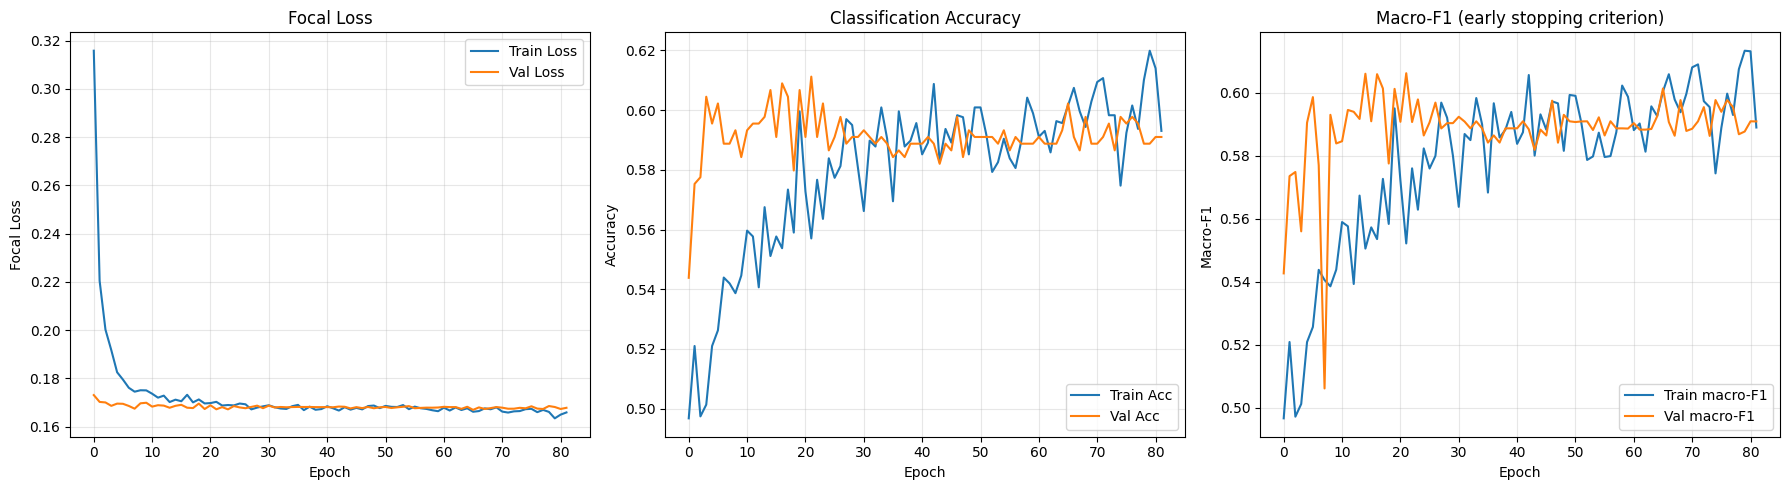

In [107]:

# Cell 13: Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses,   label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Focal Loss")
axes[0].set_title("Focal Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label="Train Acc")
axes[1].plot(val_accs,   label="Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Classification Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(train_f1s, label="Train macro-F1")
axes[2].plot(val_f1s,   label="Val macro-F1")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Macro-F1")
axes[2].set_title("Macro-F1 (early stopping criterion)"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


TEST SET EVALUATION — FOCAL LOSS BINARY MODEL
Class 0 = Not Gentrified  |  Class 1 = Gentrified

Accuracy:  0.5551

                    precision    recall  f1-score   support

Not Gentrified (0)       0.48      0.52      0.50       191
    Gentrified (1)       0.62      0.58      0.60       254

          accuracy                           0.56       445
         macro avg       0.55      0.55      0.55       445
      weighted avg       0.56      0.56      0.56       445



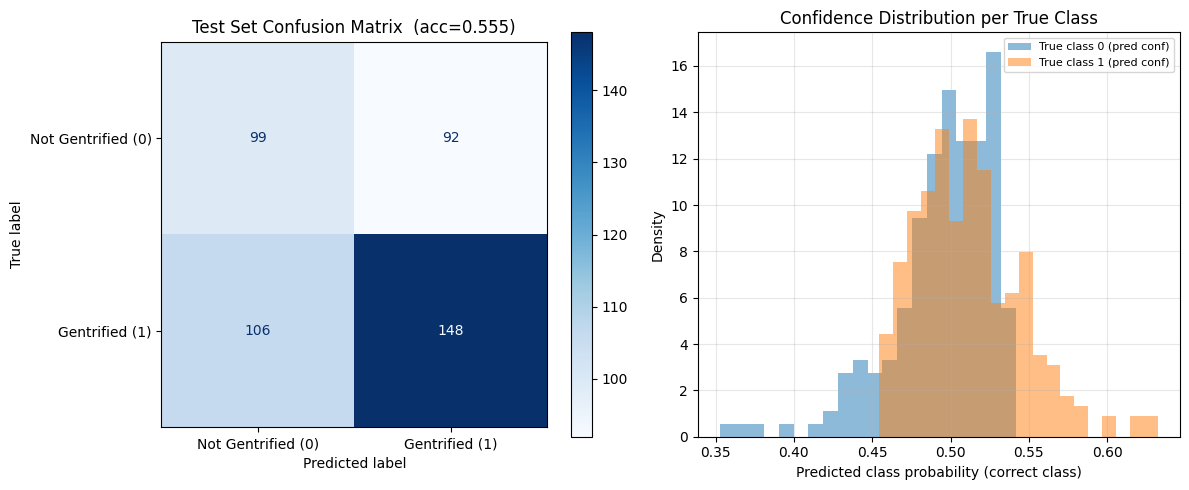

In [108]:

# Cell 14: Evaluate on test set — FocalLoss binary softmax model
model.eval()
all_cls_logits, all_labels_cls = [], []
with torch.no_grad():
    for X_batch, C_batch, y_cls_batch in test_loader:
        cls_logits = model(X_batch.to(DEVICE), C_batch.to(DEVICE))
        all_cls_logits.extend(cls_logits.cpu().numpy())
        all_labels_cls.extend(y_cls_batch.numpy())

all_cls_logits = np.array(all_cls_logits)   # (N_test, 2)
all_labels_cls = np.array(all_labels_cls)

# Softmax predictions
all_probs_cls = torch.softmax(torch.tensor(all_cls_logits), dim=1).numpy()
all_preds_cls = all_probs_cls.argmax(axis=1)
best_acc  = accuracy_score(all_labels_cls, all_preds_cls)
best_name = "FocalLoss binary softmax"

print("=" * 60)
print("TEST SET EVALUATION — FOCAL LOSS BINARY MODEL")
print("Class 0 = Not Gentrified  |  Class 1 = Gentrified")
print("=" * 60)
print(f"\nAccuracy:  {best_acc:.4f}")
print(f"\n{classification_report(all_labels_cls, all_preds_cls, target_names=['Not Gentrified (0)', 'Gentrified (1)'])}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_labels_cls, all_preds_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Gentrified (0)", "Gentrified (1)"])
disp.plot(ax=ax1, cmap="Blues")
ax1.set_title(f"Test Set Confusion Matrix  (acc={best_acc:.3f})")

# Confidence distribution per true class
for cls in range(2):
    mask = all_labels_cls == cls
    ax2.hist(all_probs_cls[mask, cls], bins=20, alpha=0.5,
             label=f"True class {cls} (pred conf)", density=True)
ax2.set_xlabel("Predicted class probability (correct class)")
ax2.set_ylabel("Density")
ax2.set_title("Confidence Distribution per True Class")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [109]:

# Cell 14b: Threshold calibration for Class 1 (Gentrified)
# Sweep P(Gentrified) threshold t ∈ [0.20, 0.60].
# Predict Gentrified (1) when P(Gentrified) >= t, else Not Gentrified (0).
# Picks the threshold maximising macro-F1 (tie-break: Gentrified F1).
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score

thresholds = np.arange(0.20, 0.61, 0.01)
results = []

for t in thresholds:
    p1 = all_probs_cls[:, 1]
    preds_t = np.where(p1 >= t, 1, 0)
    _, rec, f1_per, _ = precision_recall_fscore_support(
        all_labels_cls, preds_t, labels=[0, 1], zero_division=0)
    macro_f1 = f1_score(all_labels_cls, preds_t, average="macro", zero_division=0)
    results.append({
        "t": t, "r0": rec[0], "r1": rec[1],
        "f1_1": f1_per[1], "macro_f1": macro_f1,
        "acc": accuracy_score(all_labels_cls, preds_t),
    })

df_t = pd.DataFrame(results)

# Best: maximise macro-F1, tie-break on Gentrified F1
best_idx = df_t.sort_values(["macro_f1", "f1_1"], ascending=False).index[0]
best_t   = df_t.loc[best_idx, "t"]

print("Threshold sweep (Gentrified recall / F1  |  Macro-F1):")
print(f"{'t':>6}  {'R_notg':>8}  {'R_gent':>8}  {'F1_gent':>9}  {'MacroF1':>8}  {'Acc':>6}")
for _, row in df_t.iterrows():
    marker = " ◄ BEST" if abs(row["t"] - best_t) < 1e-6 else ""
    print(f"{row['t']:6.2f}  {row['r0']:8.3f}  {row['r1']:8.3f}  {row['f1_1']:9.3f}  "
          f"{row['macro_f1']:8.3f}  "
          f"{row['acc']:6.3f}{marker}")

print(f"\nDefault (argmax, t=0.50) — Gentrified recall: {df_t[df_t['t'].round(2)==0.50].iloc[0]['r1']:.3f}  "
      f"macro-F1: {df_t[df_t['t'].round(2)==0.50].iloc[0]['macro_f1']:.3f}")
print(f"Best t={best_t:.2f}          — Gentrified recall: {df_t.loc[best_idx,'r1']:.3f}  "
      f"macro-F1: {df_t.loc[best_idx,'macro_f1']:.3f}")

# Apply best threshold to all_preds_cls (used by downstream diagnostic cells)
p1 = all_probs_cls[:, 1]
all_preds_cls = np.where(p1 >= best_t, 1, 0)
best_acc  = accuracy_score(all_labels_cls, all_preds_cls)
best_name = f"FocalLoss binary softmax (t={best_t:.2f})"

print(f"\nFinal predictions updated with threshold t={best_t:.2f}.")
print(f"Accuracy: {best_acc:.4f}")
from sklearn.metrics import classification_report
print(classification_report(all_labels_cls, all_preds_cls,
                             target_names=["Not Gentrified (0)", "Gentrified (1)"]))


Threshold sweep (Gentrified recall / F1  |  Macro-F1):
     t    R_notg    R_gent    F1_gent   MacroF1     Acc
  0.20     0.000     1.000      0.727     0.363   0.571
  0.21     0.000     1.000      0.727     0.363   0.571
  0.22     0.000     1.000      0.727     0.363   0.571
  0.23     0.000     1.000      0.727     0.363   0.571
  0.24     0.000     1.000      0.727     0.363   0.571
  0.25     0.000     1.000      0.727     0.363   0.571
  0.26     0.000     1.000      0.727     0.363   0.571
  0.27     0.000     1.000      0.727     0.363   0.571
  0.28     0.000     1.000      0.727     0.363   0.571
  0.29     0.000     1.000      0.727     0.363   0.571
  0.30     0.000     1.000      0.727     0.363   0.571
  0.31     0.000     1.000      0.727     0.363   0.571
  0.32     0.000     1.000      0.727     0.363   0.571
  0.33     0.000     1.000      0.727     0.363   0.571
  0.34     0.000     1.000      0.727     0.363   0.571
  0.35     0.000     1.000      0.727     0.363  

Top 15 DB25 codes by embedding magnitude:
   1. DB25 682030 — norm: 4.348
   2. DB25 853260 — norm: 4.179
   3. DB25 722000 — norm: 4.133
   4. DB25 747010 — norm: 4.128
   5. DB25 889150 — norm: 4.068
   6. DB25 742000 — norm: 3.978
   7. DB25 321200 — norm: 3.916
   8. DB25 702040 — norm: 3.896
   9. DB25 889910 — norm: 3.876
  10. DB25 748490 — norm: 3.853
  11. DB25 702000 — norm: 3.802
  12. DB25 851440 — norm: 3.753
  13. DB25 821100 — norm: 3.746
  14. DB25 479119 — norm: 3.689
  15. DB25 620200 — norm: 3.656


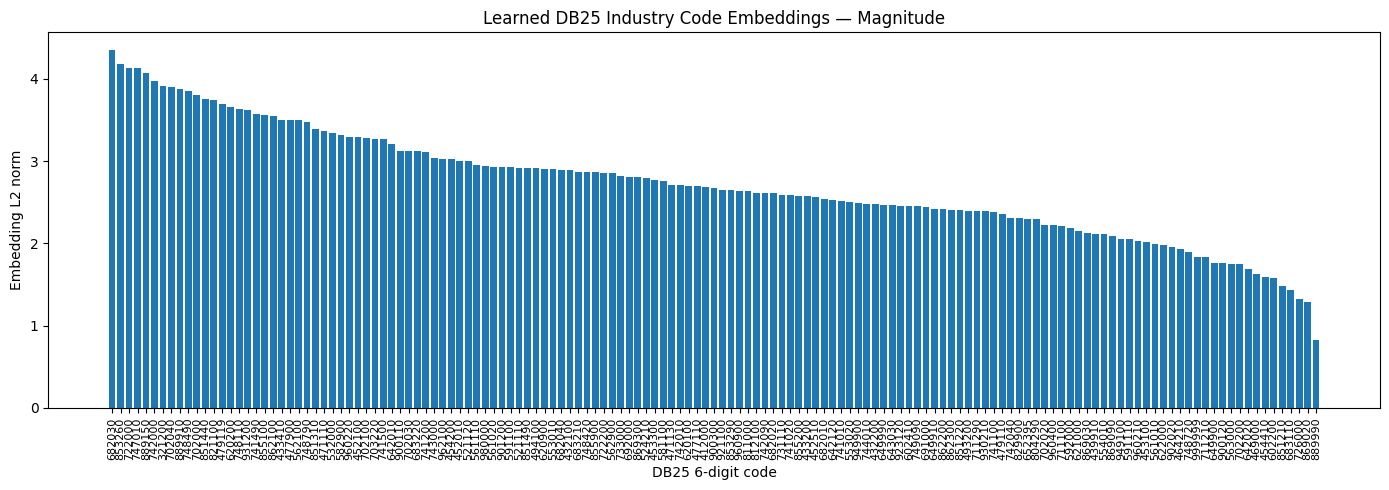

In [110]:
# Cell 15: DB25 embedding analysis — which industry codes matter most?
if hasattr(model, "db25_embedding"):
    with torch.no_grad():
        embeds = model.db25_embedding.weight.cpu().numpy()  # (num_db25, embed_dim)
    
    # Norm of each embedding = proxy for importance
    norms = np.linalg.norm(embeds, axis=1)
    order = np.argsort(norms)[::-1]
    
    print("Top 15 DB25 codes by embedding magnitude:")
    for rank, idx in enumerate(order[:15], 1):
        code = idx2db25[idx]
        print(f"  {rank:2d}. DB25 {code} — norm: {norms[idx]:.3f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    codes = [idx2db25[i] for i in order]
    ax.bar(range(len(norms)), norms[order])
    ax.set_xticks(range(len(norms)))
    ax.set_xticklabels(codes, rotation=90, fontsize=8)
    ax.set_xlabel("DB25 6-digit code")
    ax.set_ylabel("Embedding L2 norm")
    ax.set_title("Learned DB25 Industry Code Embeddings — Magnitude")
    plt.tight_layout()
    plt.show()

In [111]:

# Cell 16: Save model & predictions
MODEL_OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "db25idx": db25idx,
    "feature_cols": aug_feature_cols,
    "scaler_min":   scaler.data_min_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "coord_bounds": {
        "cx_min": float(_cx_min), "cx_max": float(_cx_max),
        "cy_min": float(_cy_min), "cy_max": float(_cy_max),
    },
    "config": {
        "input_dim":   INPUT_DIM,
        "hidden_dim":  HIDDEN_DIM,
        "num_layers":  NUM_LAYERS,
        "num_db25":    NUM_DB25,
        "embed_dim":   EMBED_DIM,
        "dropout":     DROPOUT,
        "num_classes": NUM_CLASSES,
        "spatial_dim": SPATIAL_DIM,
        "task":        "2-class binary FocalLoss classification + spatial context (0=Not Gentrified, 1=Gentrified)",
    },
}, MODEL_OUT_PATH)
print(f"Model saved to {MODEL_OUT_PATH}")

# Save predictions for all clusters
all_cluster_preds = []
model.eval()
with torch.no_grad():
    for split_name, cl_list, y_cls_arr in [
        ("train", train_clusters, y_train_cls),
        ("val",   val_clusters,   y_val_cls),
        ("test",  test_clusters,  y_test_cls),
    ]:
        X_split = build_sequences(cl_list)
        C_split = get_coords(cl_list)
        cls_logits = model(X_split.to(DEVICE), C_split.to(DEVICE))
        probs_split = torch.softmax(cls_logits, dim=1).cpu().numpy()
        p1_split = probs_split[:, 1]
        preds_cls = np.where(p1_split >= best_t, 1, 0)
        for cid, pred_class, actual_class in zip(cl_list, preds_cls, y_cls_arr):
            all_cluster_preds.append({
                "cluster_id":   cid,
                "prediction":   int(pred_class),
                "actual_class": int(actual_class),
                "split":        split_name,
            })

pred_df = pd.DataFrame(all_cluster_preds)
pred_df.to_csv(PRED_OUT_PATH, index=False)
print(f"Predictions saved to {PRED_OUT_PATH} ({len(pred_df)} clusters)")
print(f"\nClassification accuracy (full dataset): {(pred_df['prediction'] == pred_df['actual_class']).mean():.4f}")
print(f"\nPer-split accuracy:")
for sp in ["train", "val", "test"]:
    sub = pred_df[pred_df["split"] == sp]
    print(f"  {sp}: {(sub['prediction'] == sub['actual_class']).mean():.4f}  (n={len(sub)})")
pred_df.head(10)


Model saved to ..\results\models\lstm_gentrification.pt
Predictions saved to ..\results\models\lstm_predictions.csv (2224 clusters)

Classification accuracy (full dataset): 0.5733

Per-split accuracy:
  train: 0.5750  (n=1334)
  val: 0.5910  (n=445)
  test: 0.5506  (n=445)


,cluster_id,prediction,actual_class,split
0,167_49,1,1,train
1,101_375,0,0,train
2,101_120,0,0,train
3,101_899,0,0,train
4,155_38,1,0,train
5,101_348,0,1,train
6,101_562,0,1,train
7,153_52,1,0,train
8,101_742,0,1,train
9,101_267,0,0,train


In [112]:

# Cell 17: 5-Fold Stratified Cross-Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler as _MMS

N_FOLDS     = 5
CV_EPOCHS   = 200
CV_PATIENCE = 30

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Full labelled cluster set (train+val+test combined)
all_clusters_arr = np.array(train_clusters + val_clusters + test_clusters)
all_y_cls_arr    = np.concatenate([y_train_cls, y_val_cls, y_test_cls])

fold_results = []
print(f"5-Fold CV  |  architecture: BiLSTM({HIDDEN_DIM}×2, {NUM_LAYERS}L) + FocalLoss  |  binary: Stable vs Gentrifying")
print("-" * 70)

for fold, (tr_idx, te_idx) in enumerate(skf.split(all_clusters_arr, all_y_cls_arr), 1):
    fold_cl_train = all_clusters_arr[tr_idx].tolist()
    fold_cl_test  = all_clusters_arr[te_idx].tolist()
    fold_y_train  = all_y_cls_arr[tr_idx]
    fold_y_test   = all_y_cls_arr[te_idx]

    # Build sequences with fold-local scaler
    fold_scaler  = _MMS()
    X_fold_train = build_sequences(fold_cl_train, fit_scaler=True,  scaler_obj=fold_scaler)
    X_fold_test  = build_sequences(fold_cl_test,  fit_scaler=False, scaler_obj=fold_scaler)
    C_fold_train = get_coords(fold_cl_train)
    C_fold_test  = get_coords(fold_cl_test)

    # SMOTE
    X_fold_aug, C_fold_aug, y_fold_aug = sequence_smote(
        X_fold_train, C_fold_train, fold_y_train)
    y_fold_aug_t  = torch.tensor(y_fold_aug, dtype=torch.long)
    y_fold_test_t = torch.tensor(fold_y_test, dtype=torch.long)

    ds_tr = GentrificationDataset(X_fold_aug,  C_fold_aug,  y_fold_aug_t)
    ds_te = GentrificationDataset(X_fold_test, C_fold_test, y_fold_test_t)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)
    dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE)

    cls_counts_fold = np.bincount(y_fold_aug, minlength=NUM_CLASSES).astype(float)
    cls_w_fold = torch.tensor(1.0 / np.maximum(cls_counts_fold, 1), dtype=torch.float32).to(DEVICE)
    fold_criterion = FocalLoss(alpha=cls_w_fold, gamma=FOCAL_GAMMA)

    fold_model = GentrificationLSTM(
        input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
        num_db25=NUM_DB25, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
        dropout=DROPOUT, spatial_dim=SPATIAL_DIM,
    ).to(DEVICE)
    fold_opt   = torch.optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=2e-2)
    fold_sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        fold_opt, T_0=40, T_mult=2, eta_min=1e-6)

    best_fold_f1, best_fold_state, fold_pat = 0.0, None, 0

    for ep in range(1, CV_EPOCHS + 1):
        fold_model.train()
        for X_b, C_b, y_b in dl_tr:
            fold_opt.zero_grad()
            logits = fold_model(add_noise(X_b.to(DEVICE), NOISE_STD), C_b.to(DEVICE))
            loss   = fold_criterion(logits, y_b.to(DEVICE))
            loss.backward()
            nn.utils.clip_grad_norm_(fold_model.parameters(), GRAD_CLIP)
            fold_opt.step()
        fold_sched.step()

        if ep % 5 == 0 or ep == CV_EPOCHS:
            fold_model.eval()
            ep_preds, ep_true = [], []
            with torch.no_grad():
                for X_b, C_b, y_b in dl_te:
                    lg = fold_model(X_b.to(DEVICE), C_b.to(DEVICE))
                    ep_preds.extend(torch.argmax(lg, dim=1).cpu().numpy())
                    ep_true.extend(y_b.numpy())
            ep_f1 = f1_score(ep_true, ep_preds, average="macro", zero_division=0)
            if ep_f1 > best_fold_f1:
                best_fold_f1   = ep_f1
                best_fold_state = {k: v.cpu().clone() for k, v in fold_model.state_dict().items()}
                fold_pat = 0
            else:
                fold_pat += 5
            if fold_pat >= CV_PATIENCE:
                break

    fold_model.load_state_dict(best_fold_state)
    fold_model.to(DEVICE).eval()
    fold_preds, fold_true = [], []
    with torch.no_grad():
        for X_b, C_b, y_b in dl_te:
            lg = fold_model(X_b.to(DEVICE), C_b.to(DEVICE))
            fold_preds.extend(torch.argmax(lg, dim=1).cpu().numpy())
            fold_true.extend(y_b.numpy())

    fold_acc  = accuracy_score(fold_true, fold_preds)
    fold_f1   = f1_score(fold_true, fold_preds, average="macro", zero_division=0)
    _, fold_r, _, _ = precision_recall_fscore_support(
        fold_true, fold_preds, labels=[0, 1], zero_division=0)
    fold_results.append({"fold": fold, "acc": fold_acc, "macro_f1": fold_f1,
                          "r0": fold_r[0], "r1": fold_r[1]})
    print(f"  Fold {fold}  acc={fold_acc:.3f}  macro-F1={fold_f1:.3f}  "
          f"recall=[stable={fold_r[0]:.3f}, gent={fold_r[1]:.3f}]")

cv_df = pd.DataFrame(fold_results)
print("\n" + "=" * 70)
print("5-FOLD CV SUMMARY")
print("=" * 70)
for metric, label in [("acc","Accuracy"),("macro_f1","Macro-F1"),
                       ("r0","Recall Stable (0)"),("r1","Recall Gentrifying (1)")]:
    print(f"  {label:<22}: {cv_df[metric].mean():.4f} ± {cv_df[metric].std():.4f}")
ci = cv_df["macro_f1"].mean()
ci_w = 2 * cv_df["macro_f1"].std()
print(f"\n  95% CI macro-F1: [{ci - ci_w:.4f}, {ci + ci_w:.4f}]")


5-Fold CV  |  architecture: BiLSTM(32×2, 1L) + FocalLoss  |  binary: Stable vs Gentrifying
----------------------------------------------------------------------
  Fold 1  acc=0.537  macro-F1=0.526  recall=[stable=0.453, gent=0.600]
  Fold 2  acc=0.499  macro-F1=0.495  recall=[stable=0.484, gent=0.510]
  Fold 3  acc=0.515  macro-F1=0.510  recall=[stable=0.492, gent=0.531]
  Fold 4  acc=0.524  macro-F1=0.521  recall=[stable=0.529, gent=0.520]
  Fold 5  acc=0.563  macro-F1=0.563  recall=[stable=0.632, gent=0.512]

5-FOLD CV SUMMARY
  Accuracy              : 0.5274 ± 0.0243
  Macro-F1              : 0.5232 ± 0.0252
  Recall Stable (0)     : 0.5179 ± 0.0691
  Recall Gentrifying (1): 0.5346 ± 0.0376

  95% CI macro-F1: [0.4729, 0.5735]


In [118]:

# Save LSTM probabilities for ensemble notebook
PROBA_OUT_PATH = Path("../results/models/lstm_proba_cph.csv")

lstm_proba_rows = []
model.eval()
with torch.no_grad():
    for split_name, cl_list, y_cls_arr in [
        ("train", train_clusters, y_train_cls),
        ("val",   val_clusters,   y_val_cls),
        ("test",  test_clusters,  y_test_cls),
    ]:
        X_split = build_sequences(cl_list)
        C_split = get_coords(cl_list)
        cls_logits = model(X_split.to(DEVICE), C_split.to(DEVICE))
        probs_split = torch.softmax(cls_logits, dim=1).cpu().numpy()
        for cid, p0, p1, true_cls in zip(cl_list, probs_split[:, 0], probs_split[:, 1], y_cls_arr):
            lstm_proba_rows.append({
                "cluster_id":       cid,
                "p_not_gentrified": float(p0),
                "p_gentrified":     float(p1),
                "actual_class":     int(true_cls),
                "split":            split_name,
            })

lstm_proba_df = pd.DataFrame(lstm_proba_rows)
lstm_proba_df.to_csv(PROBA_OUT_PATH, index=False)
print(f"Saved LSTM probabilities: {PROBA_OUT_PATH}  (rows={len(lstm_proba_df)})")
print(lstm_proba_df['split'].value_counts().sort_index())
print(lstm_proba_df.head())


Saved LSTM probabilities: ..\results\models\lstm_proba_cph.csv  (rows=2224)
split
test      445
train    1334
val       445
Name: count, dtype: int64
  cluster_id  p_not_gentrified  p_gentrified  actual_class  split
0     167_49          0.423958      0.576042             1  train
1    101_375          0.505105      0.494895             0  train
2    101_120          0.533170      0.466830             0  train
3    101_899          0.522377      0.477623             0  train
4     155_38          0.489206      0.510794             0  train


## Phase 4 — Evaluation & Diagnostics

DETAILED BINARY EVALUATION  (test set)
Class 0 = Not Gentrified  |  Class 1 = Gentrified

Class distribution (counts):
Class                 Train      Val     Test    Total
  Not Gentrified (0)      571      190      191      952
  Gentrified (1)      763      255      254     1272
  TOTAL                1334      445      445     2224

Per-class precision / recall / F1 (test set):
Class                 Precision     Recall         F1    Support
  Not Gentrified (0)      0.483      0.654      0.556        191
  Gentrified (1)        0.645      0.472      0.545        254
  macro                 0.564      0.563      0.551
  wt avg                0.575      0.551      0.550

Balanced accuracy : 0.5634   (vs raw acc 0.5506)
Cohen's kappa     : 0.1215   (0=chance, 1=perfect)
AUC-ROC           : 0.5652

Mean confidence (max class prob):
  Correct predictions : 0.527
  Wrong predictions   : 0.524


C:\Users\jonas\AppData\Local\Temp\ipykernel_19056\2944410783.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(conf_by_class, labels=["Not Gentrified (0)", "Gentrified (1)"],


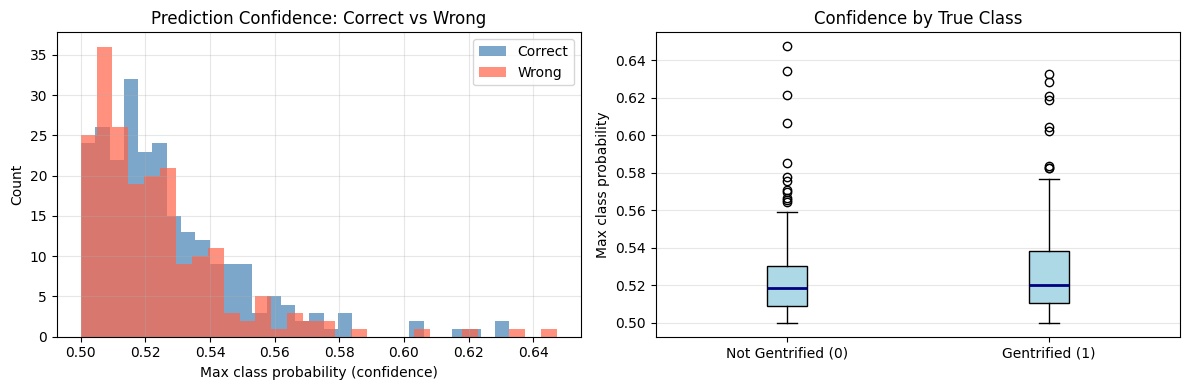

In [113]:

# Cell 17: Per-class metrics — precision/recall/F1, AUC-ROC, balanced accuracy
from scipy.stats import spearmanr
from sklearn.metrics import (
    precision_recall_fscore_support, balanced_accuracy_score,
    roc_auc_score, cohen_kappa_score
)

print("=" * 65)
print("DETAILED BINARY EVALUATION  (test set)")
print("Class 0 = Not Gentrified  |  Class 1 = Gentrified")
print("=" * 65)

# ── Class distribution across splits ──
print("\nClass distribution (counts):")
print(f"{'Class':<18} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
for c in range(2):
    tr = (y_train_cls == c).sum()
    va = (y_val_cls   == c).sum()
    te = (y_test_cls  == c).sum()
    lbl = "Not Gentrified (0)" if c == 0 else "Gentrified (1)"
    print(f"  {lbl:<14} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}")
print(f"  {'TOTAL':<16} {len(y_train_cls):>8} {len(y_val_cls):>8} {len(y_test_cls):>8} {len(y_all_class):>8}")

# ── Per-class P/R/F1 ──
print("\nPer-class precision / recall / F1 (test set):")
p, r, f, sup = precision_recall_fscore_support(
    all_labels_cls, all_preds_cls, labels=[0, 1], zero_division=0
)
print(f"{'Class':<20} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
for c, name in enumerate(["Not Gentrified (0)", "Gentrified (1)"]):
    print(f"  {name:<16} {p[c]:>10.3f} {r[c]:>10.3f} {f[c]:>10.3f} {sup[c]:>10}")
p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(
    all_labels_cls, all_preds_cls, average="macro", zero_division=0)
p_wt, r_wt, f_wt, _ = precision_recall_fscore_support(
    all_labels_cls, all_preds_cls, average="weighted", zero_division=0)
print(f"  {'macro':<16} {p_mac:>10.3f} {r_mac:>10.3f} {f_mac:>10.3f}")
print(f"  {'wt avg':<16} {p_wt:>10.3f} {r_wt:>10.3f} {f_wt:>10.3f}")

# ── Aggregate metrics ──
bal_acc = balanced_accuracy_score(all_labels_cls, all_preds_cls)
kappa   = cohen_kappa_score(all_labels_cls, all_preds_cls)
print(f"\nBalanced accuracy : {bal_acc:.4f}   (vs raw acc {best_acc:.4f})")
print(f"Cohen's kappa     : {kappa:.4f}   (0=chance, 1=perfect)")

# ── AUC-ROC — binary classification ──
y_prob = torch.softmax(torch.tensor(all_cls_logits, dtype=torch.float32), dim=1).numpy()  # (N, 2)
try:
    auc_score = roc_auc_score(all_labels_cls, y_prob[:, 1])
    print(f"AUC-ROC           : {auc_score:.4f}")
except Exception as e:
    print(f"AUC-ROC skipped: {e}")

# ── Confidence distribution by class ──
max_prob = y_prob.max(axis=1)
correct_mask = (all_preds_cls == all_labels_cls)
print(f"\nMean confidence (max class prob):")
print(f"  Correct predictions : {max_prob[correct_mask].mean():.3f}")
print(f"  Wrong predictions   : {max_prob[~correct_mask].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(max_prob[correct_mask], bins=30, alpha=0.7, label="Correct", color="steelblue")
axes[0].hist(max_prob[~correct_mask], bins=30, alpha=0.7, label="Wrong",   color="tomato")
axes[0].set_xlabel("Max class probability (confidence)")
axes[0].set_ylabel("Count")
axes[0].set_title("Prediction Confidence: Correct vs Wrong")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

conf_by_class = [max_prob[all_labels_cls == c] for c in range(2)]
axes[1].boxplot(conf_by_class, labels=["Not Gentrified (0)", "Gentrified (1)"],
                patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="navy", lw=2))
axes[1].set_ylabel("Max class probability")
axes[1].set_title("Confidence by True Class")
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


  BINARY CLASSIFICATION — PERFORMANCE SUMMARY (test set)
  Not Gentrified (0)  vs  Gentrified (1)  |  threshold = 0.51
  Accuracy              : 0.5506
  Balanced accuracy     : 0.5634
  Macro F1              : 0.5505
  Weighted F1           : 0.5498
  Cohen's kappa         : 0.1215   (>0.4 = moderate)
  AUC-ROC               : 0.5652
  Avg precision (PR-AUC): 0.6196
--------------------------------------------------------------
                    precision    recall  f1-score   support

Not Gentrified (0)      0.483     0.654     0.556       191
    Gentrified (1)      0.645     0.472     0.545       254

          accuracy                          0.551       445
         macro avg      0.564     0.563     0.551       445
      weighted avg      0.575     0.551     0.550       445



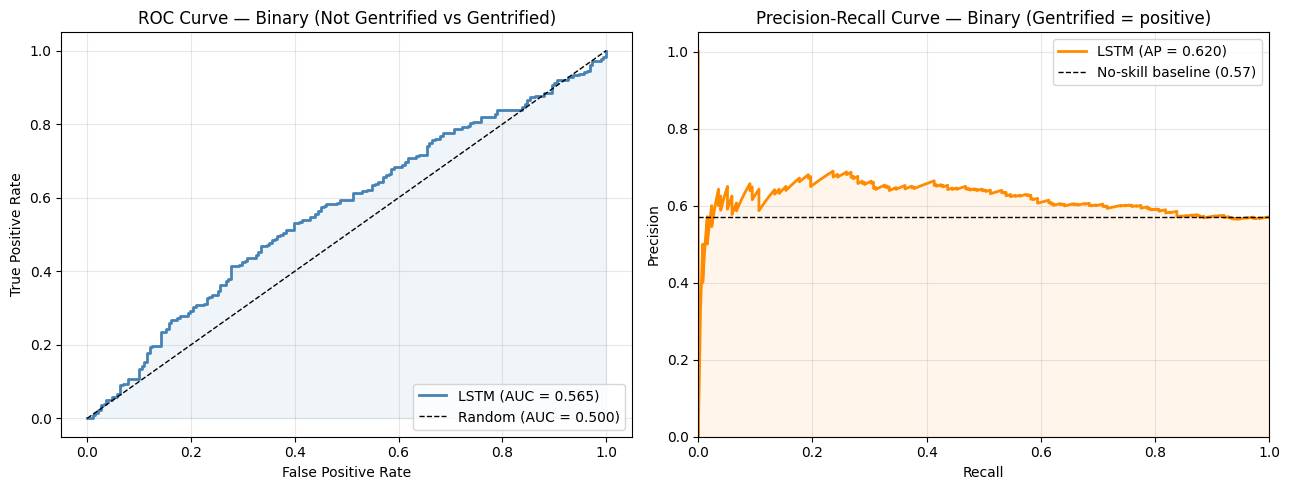


5-Fold CV summary:
  Accuracy         : 0.5274 ± 0.0243
  Macro-F1         : 0.5232 ± 0.0252
  Recall Not Gentrified: 0.5179 ± 0.0691
  Recall Gentrified    : 0.5346 ± 0.0376
  95% CI macro-F1: [0.4729, 0.5735]


In [114]:

# Cell 17b: Binary classification performance summary — ROC curve, PR curve, summary table
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, balanced_accuracy_score, cohen_kappa_score,
    accuracy_score, classification_report
)

# ── Softmax probabilities for positive class (Gentrified = 1) ──
y_prob_bin = torch.softmax(
    torch.tensor(all_cls_logits, dtype=torch.float32), dim=1
).numpy()                      # (N_test, 2)
y_score_pos = y_prob_bin[:, 1] # P(Gentrified)

# ─────────────────────────────────────────
# 1. Metrics summary
# ─────────────────────────────────────────
acc      = accuracy_score(all_labels_cls, all_preds_cls)
bal_acc  = balanced_accuracy_score(all_labels_cls, all_preds_cls)
kappa    = cohen_kappa_score(all_labels_cls, all_preds_cls)
macro_f1 = f1_score(all_labels_cls, all_preds_cls, average="macro",    zero_division=0)
wt_f1    = f1_score(all_labels_cls, all_preds_cls, average="weighted", zero_division=0)
roc_auc  = auc(*roc_curve(all_labels_cls, y_score_pos)[:2])
ap_score = average_precision_score(all_labels_cls, y_score_pos)

print("=" * 62)
print("  BINARY CLASSIFICATION — PERFORMANCE SUMMARY (test set)")
print("  Not Gentrified (0)  vs  Gentrified (1)  |  threshold = {:.2f}".format(best_t))
print("=" * 62)
print(f"  Accuracy              : {acc:.4f}")
print(f"  Balanced accuracy     : {bal_acc:.4f}")
print(f"  Macro F1              : {macro_f1:.4f}")
print(f"  Weighted F1           : {wt_f1:.4f}")
print(f"  Cohen's kappa         : {kappa:.4f}   (>0.4 = moderate)")
print(f"  AUC-ROC               : {roc_auc:.4f}")
print(f"  Avg precision (PR-AUC): {ap_score:.4f}")
print("-" * 62)
print(classification_report(
    all_labels_cls, all_preds_cls,
    target_names=["Not Gentrified (0)", "Gentrified (1)"],
    digits=3
))

# ─────────────────────────────────────────
# 2. ROC curve
# ─────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_labels_cls, y_score_pos)
prec, rec_pr, _ = precision_recall_curve(all_labels_cls, y_score_pos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(fpr, tpr, lw=2, color="steelblue", label=f"LSTM (AUC = {roc_auc:.3f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.500)")
ax1.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve — Binary (Not Gentrified vs Gentrified)")
ax1.legend(loc="lower right"); ax1.grid(True, alpha=0.3)

# ─────────────────────────────────────────
# 3. Precision-Recall curve
# ─────────────────────────────────────────
baseline_pr = (all_labels_cls == 1).mean()   # prevalence of Gentrified class
ax2.plot(rec_pr, prec, lw=2, color="darkorange", label=f"LSTM (AP = {ap_score:.3f})")
ax2.axhline(baseline_pr, color="k", lw=1, linestyle="--",
            label=f"No-skill baseline ({baseline_pr:.2f})")
ax2.fill_between(rec_pr, prec, alpha=0.08, color="darkorange")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve — Binary (Gentrified = positive)")
ax2.legend(loc="upper right"); ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# 4. CV summary (if available)
# ─────────────────────────────────────────
if "cv_df" in dir():
    print("\n5-Fold CV summary:")
    print(f"  Accuracy         : {cv_df['acc'].mean():.4f} ± {cv_df['acc'].std():.4f}")
    print(f"  Macro-F1         : {cv_df['macro_f1'].mean():.4f} ± {cv_df['macro_f1'].std():.4f}")
    print(f"  Recall Not Gentrified: {cv_df['r0'].mean():.4f} ± {cv_df['r0'].std():.4f}")
    print(f"  Recall Gentrified    : {cv_df['r1'].mean():.4f} ± {cv_df['r1'].std():.4f}")
    ci_lo = cv_df['macro_f1'].mean() - 2 * cv_df['macro_f1'].std()
    ci_hi = cv_df['macro_f1'].mean() + 2 * cv_df['macro_f1'].std()
    print(f"  95% CI macro-F1: [{ci_lo:.4f}, {ci_hi:.4f}]")


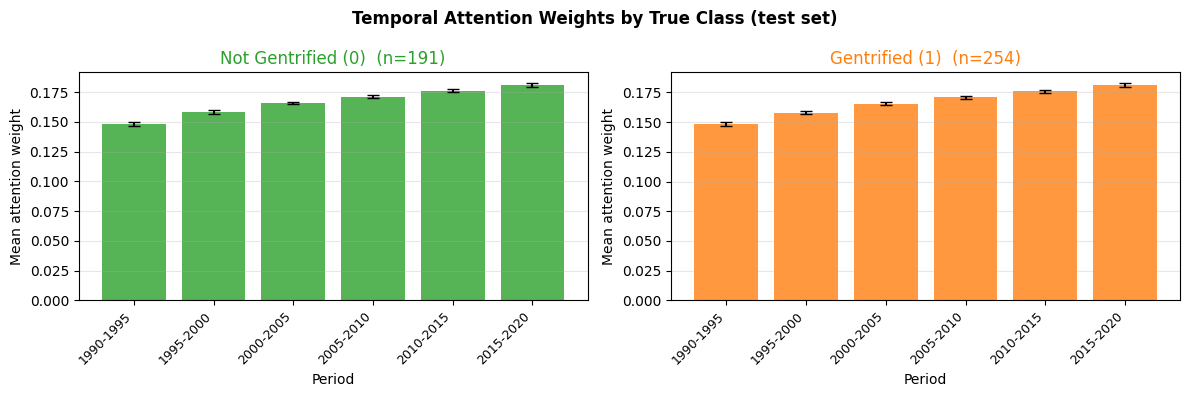

Mean attention per period (all test classes):
  1990-1995: 0.1483  ±0.0017
  1995-2000: 0.1581  ±0.0014
  2000-2005: 0.1656  ±0.0010
  2005-2010: 0.1711  ±0.0011
  2010-2015: 0.1759  ±0.0014
  2015-2020: 0.1809  ±0.0017


In [115]:

# Cell 18: Attention weight analysis — which time periods the model focuses on
model.eval()
attn_by_class = {0: [], 1: []}

with torch.no_grad():
    for X_batch, C_batch, y_cls_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        C_batch = C_batch.to(DEVICE)
        _, attn = model(X_batch, C_batch, return_attention=True)  # (B, T)
        attn_np = attn.cpu().numpy()
        for i, cls_label in enumerate(y_cls_batch.numpy()):
            attn_by_class[int(cls_label)].append(attn_np[i])

period_labels = [f"{s}-{e}" for s, e in PERIODS]
cls_names = ["Not Gentrified (0)", "Gentrified (1)"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
class_colors = ["#2ca02c", "#ff7f0e"]

for c in range(2):
    attn_arr = np.array(attn_by_class[c])   # (N_cls, T)
    mean_attn = attn_arr.mean(axis=0)
    std_attn  = attn_arr.std(axis=0)
    axes[c].bar(range(NUM_PERIODS), mean_attn, color=class_colors[c], alpha=0.8,
                yerr=std_attn, capsize=4)
    axes[c].set_xticks(range(NUM_PERIODS))
    axes[c].set_xticklabels(period_labels, rotation=45, ha="right", fontsize=9)
    axes[c].set_title(f"{cls_names[c]}  (n={len(attn_by_class[c])})", color=class_colors[c])
    axes[c].set_ylabel("Mean attention weight")
    axes[c].set_xlabel("Period")
    axes[c].grid(True, alpha=0.3, axis="y")
    axes[c].set_ylim(0, None)

plt.suptitle("Temporal Attention Weights by True Class (test set)", fontweight="bold")
plt.tight_layout()
plt.show()

all_attn = np.concatenate([np.array(v) for v in attn_by_class.values()], axis=0)
print("Mean attention per period (all test classes):")
for i, (ps, pe) in enumerate(PERIODS):
    print(f"  {ps}-{pe}: {all_attn[:, i].mean():.4f}  ±{all_attn[:, i].std():.4f}")


ERROR ANALYSIS — TEST SET  (binary: Not Gentrified vs Gentrified)

Total test samples  : 445
Correct predictions : 245 (55.1%)
Wrong predictions   : 200

Confusion breakdown (Actual → Predicted):
  True Not Gentrified → Pred Gentrified:  66 samples
  True Gentrified → Pred Not Gentrified: 134 samples

Mean confidence — correct vs wrong:
  Correct: 0.5274
  Wrong  : 0.5239


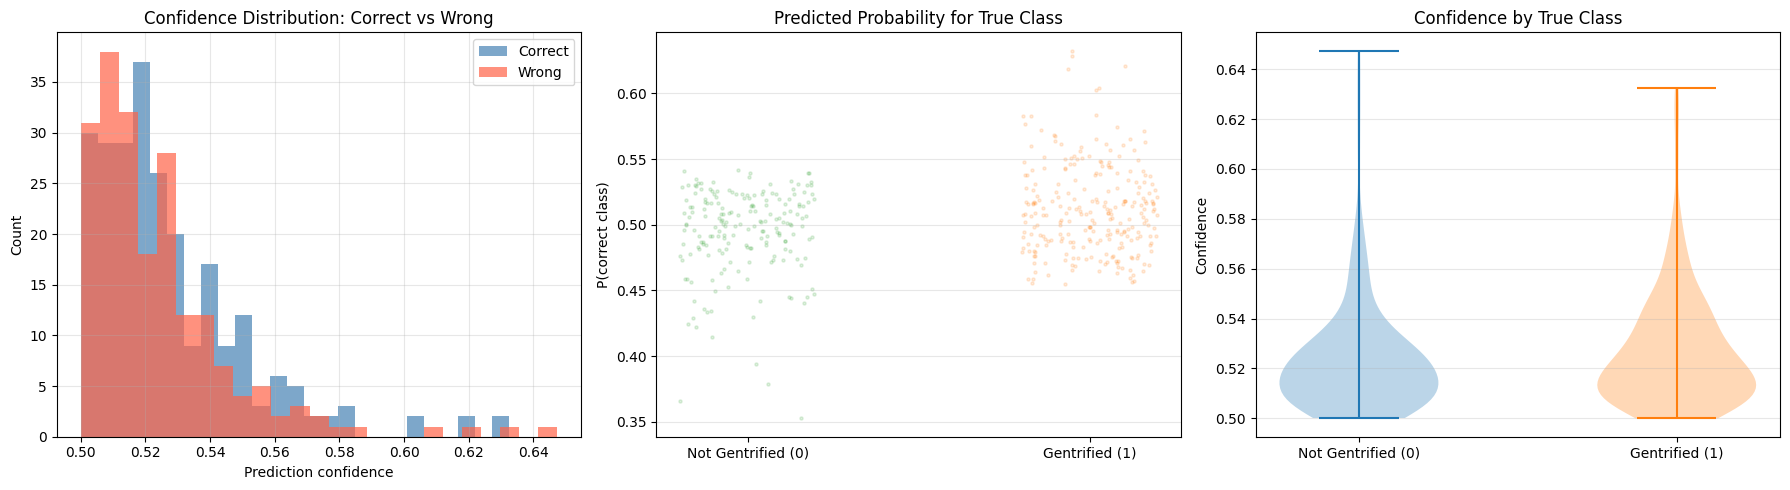


High-uncertainty errors (conf < 0.55): 180 / 200
cluster_id  actual_class  prediction  confidence
    159_56             1           0    0.529590
   101_228             0           1    0.510639
   147_116             1           0    0.502940
   101_442             1           0    0.514204
    157_58             1           0    0.503210
   101_373             1           0    0.501668
   101_954             0           1    0.512942
   101_686             1           0    0.509019
   101_520             1           0    0.520544
   101_390             0           1    0.540926
   101_308             1           0    0.505293
    101_25             1           0    0.520641
    185_24             1           0    0.507169
   157_133             1           0    0.527739
   101_263             1           0    0.507311


In [116]:

# Cell 19: Error analysis — where does the model fail?
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

pred_df_test = pred_df[pred_df["split"] == "test"].copy()
pred_df_test["correct"] = pred_df_test["prediction"] == pred_df_test["actual_class"]

# ── Prediction confidence for each test sample (softmax probabilities) ──
y_prob_test_list = []
model.eval()
with torch.no_grad():
    for X_batch, C_batch, y_cls_batch in test_loader:
        cls_logits = model(X_batch.to(DEVICE), C_batch.to(DEVICE))
        probs = torch.softmax(cls_logits, dim=1)   # (B, 2)
        y_prob_test_list.append(probs.cpu().numpy())
y_prob_test = np.vstack(y_prob_test_list)   # (N_test, 2)

pred_df_test["confidence"] = y_prob_test.max(axis=1)

print("=" * 60)
print("ERROR ANALYSIS — TEST SET  (binary: Not Gentrified vs Gentrified)")
print("=" * 60)
print(f"\nTotal test samples  : {len(pred_df_test)}")
print(f"Correct predictions : {pred_df_test['correct'].sum()} ({pred_df_test['correct'].mean():.1%})")
print(f"Wrong predictions   : {(~pred_df_test['correct']).sum()}")

print("\nConfusion breakdown (Actual → Predicted):")
wrong = pred_df_test[~pred_df_test["correct"]]
cls_names = {0: "Not Gentrified", 1: "Gentrified"}
for actual in range(2):
    for predicted in range(2):
        if actual == predicted:
            continue
        n = ((wrong["actual_class"] == actual) & (wrong["prediction"] == predicted)).sum()
        if n > 0:
            print(f"  True {cls_names[actual]} → Pred {cls_names[predicted]}: {n:3d} samples")

print("\nMean confidence — correct vs wrong:")
print(f"  Correct: {pred_df_test.loc[pred_df_test['correct'],  'confidence'].mean():.4f}")
print(f"  Wrong  : {pred_df_test.loc[~pred_df_test['correct'], 'confidence'].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Confidence by error type ──
corr_conf  = pred_df_test.loc[ pred_df_test["correct"], "confidence"]
wrong_conf = pred_df_test.loc[~pred_df_test["correct"], "confidence"]
axes[0].hist(corr_conf,  bins=25, alpha=0.7, label="Correct", color="steelblue")
axes[0].hist(wrong_conf, bins=25, alpha=0.7, label="Wrong",   color="tomato")
axes[0].set_xlabel("Prediction confidence"); axes[0].set_ylabel("Count")
axes[0].set_title("Confidence Distribution: Correct vs Wrong")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── 2. Class probability distributions ──
colors = ["#2ca02c", "#ff7f0e"]
for c in range(2):
    y_prob_cls = y_prob_test[np.where(all_labels_cls == c)[0]]
    axes[1].scatter(np.full(len(y_prob_cls), c) + np.random.uniform(-0.2, 0.2, len(y_prob_cls)),
                    y_prob_cls[:, c], alpha=0.15, s=5, color=colors[c])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Not Gentrified (0)", "Gentrified (1)"])
axes[1].set_ylabel("P(correct class)")
axes[1].set_title("Predicted Probability for True Class")
axes[1].grid(True, alpha=0.3, axis="y")

# ── 3. Confidence by actual class ──
for c in range(2):
    mask = pred_df_test["actual_class"] == c
    axes[2].violinplot(pred_df_test.loc[mask, "confidence"], positions=[c])
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["Not Gentrified (0)", "Gentrified (1)"])
axes[2].set_ylabel("Confidence"); axes[2].set_title("Confidence by True Class")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ── Low-confidence errors ──
low_conf_threshold = 0.55
low_conf_errors = pred_df_test[~pred_df_test["correct"] & (pred_df_test["confidence"] < low_conf_threshold)]
print(f"\nHigh-uncertainty errors (conf < {low_conf_threshold}): {len(low_conf_errors)} / {(~pred_df_test['correct']).sum()}")
if len(low_conf_errors) > 0:
    print(low_conf_errors[["cluster_id", "actual_class", "prediction", "confidence"]].head(15).to_string(index=False))
